# 멀티 모달 : 이미지 분석하기

In [1]:
from dotenv import load_dotenv
import os

# .env 파일 불러오기
load_dotenv("C:/env/.env")

# 환경 변수 가져오기
API_KEY = os.getenv("OPENAI_API_KEY")

from openai import OpenAI
client = OpenAI(api_key=API_KEY)

### [1] 이미지 입력하기

In [2]:
# !pip install Pillow
# !pip install matplotlib
# !pip install "numpy<2"
# 코드 후반 부에서  opencv 설치후 다시 numpy 버전이 2.x로 변경 됨을 주의 --> 다시 numpy 버전 2.x미만으로 다시 설치 필요

c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


상태 코드: 200
Content-Type: image/jpeg
파일 크기: 762959


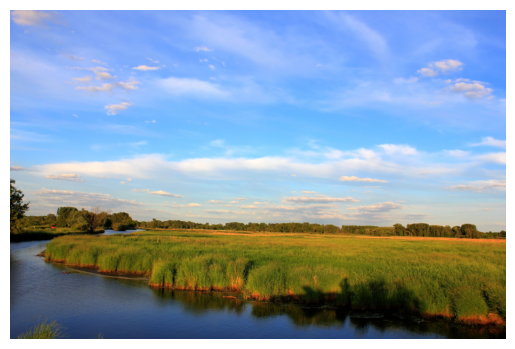

In [ ]:

import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

# url 링크 자주 변경됨!!
wisconsin_url = "https://upload.wikimedia.org/wikipedia/commons/5/57/Gfp-wisconsin-madison-skies-over-wetland.jpg"         # 현재 사용 가능
# wisconsin_url = "https://upload.wikimedia.org/wikipedia/commons/d/d9/Gfp-wisconsin-madison-streams-of-the-wetlands.jpg"  # 현재 사용 가능

# User-Agent 추가 (일부 서버는 필요)
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(wisconsin_url, headers=headers)

print("상태 코드:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("파일 크기:", len(response.content))

response.raise_for_status()

# 이미지 열기
img = Image.open(BytesIO(response.content))

plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
# 이미지 입력 질의
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages = [
        {
            "role":"user",
            "content":[
                {"type":"text","text": "이 이미지에 무엇이 있나요?"},
                {
                  "type":"image_url",
                  "image_url": {
                      "url": wisconsin_url
                  },  
                },
            ],
        }
    ],
    max_tokens =300,
)

print(response.choices[0].message.content)

이 이미지는 강이나 시내가 흐르고 있는 평화로운 풍경을 담고 있습니다. 둘러싼 지역에는 푸른 풀과 나무들이 있으며, 하늘은 파란색과 구름으로 가득 차 있습니다. 전반적으로 자연의 아름다움을 느낄 수 있는 장면입니다.


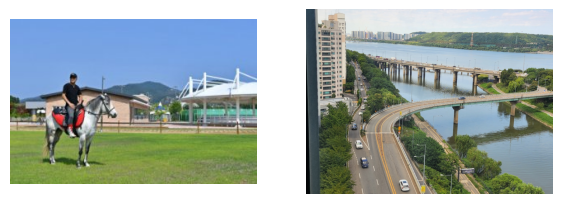

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# 로컬 경로에 있는 이미지를 불러옵니다.
image_path1 = 'horse.jpg'
image_path2 = 'river.jpg'

# 이미지를 열어줍니다.
img1 = Image.open(image_path1)
img2 = Image.open(image_path2)

# 이미지를 출력합니다.
fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img1)
axes[0].axis('off')  # 축 제거
axes[1].imshow(img2)
axes[1].axis('off')  # 축 제거
plt.show()

In [6]:
# base64 encoding web service 
# https://vivoldi.com/tools/base64-encoding-decoding
# https://www.base64encode.net/base64-image-encoder

In [7]:
import base64

# base64 encode the image
def encode_image(image_path):
    with open(image_path,"rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# image_path = "horse.jpg"
image_path = "river.jpg"

base64_image = encode_image(image_path)
# print(base64_image)

# 이미지 입력 질의
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages = [
        {
            "role":"user",
            "content":[
                {"type":"text","text": "이 이미지에 무엇이 있나요?"},
                {
                  "type":"image_url",
                  "image_url": {
                      "url": f"data:image/jpeg;base64,{base64_image}"
                  },  
                },
            ],
        }
    ],
    max_tokens =300,
)

print(response.choices[0].message.content)

이미지에는 한강으로 보이는 수변과 주변의 도로, 교량이 포함되어 있습니다. 왼쪽에는 아파트 건물이 보이며, 강가에는 나무와 풀이 자생해 있습니다. 도로에는 차량이 움직이고 있으며, 교량이 강을 가로지르는 모습이 담겨 있습니다. 전체적으로 자연과 도시 환경이 조화를 이루고 있는 장면입니다.


## [2] 이미지 세밀한 분석
: "gpt-4o-mini" 버전은 성능이 좋지 않음. "gpt-4o" 사용 추천

In [8]:
import base64

# base64 encode the image
def encode_image(image_path):
    with open(image_path,"rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# image_path = "horse.jpg"
image_path = "river.jpg"

base64_image = encode_image(image_path)
# print(base64_image)

# 이미지 입력 질의
response = client.chat.completions.create(
    # model="gpt-4o-mini",  # 답변 못함
    model="gpt-4o",         # 15~25대 범위로 답변
    # model="gpt-5",        # 대략 20대
    
    messages = [
        {
            "role":"user",
            "content":[
                {"type":"text","text": "이 이미지에는 자동차가 몇대 있나요?"},
                {
                  "type":"image_url",
                  "image_url": {
                      "url": f"data:image/jpeg;base64,{base64_image}"
                  },  
                },
            ],
        }
    ],
    max_tokens =300,
)

print(response.choices[0].message.content)

이미지에는 총 14대의 자동차가 있습니다.


## [3] 여러 개의 이미지 사용하기

In [9]:
# 동일한 이미지 입력 질의
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role":"user",
            "content": [
                { "type":"text","text":"이 이미지들에 무엇이 있나요? 이들 사이에 차이가 있나요?" },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": wisconsin_url      
                    },
                },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": wisconsin_url
                    },
                },
            ],
        }
    ],
    max_tokens=300,    
)

print(response.choices[0].message.content)

이 두 이미지는 동일한 풍경을 보여주는 것으로 보이며, 색상이나 구도, 구름의 배치 등에서 큰 차이는 없습니다. 따라서 둘 사이에는 눈에 띄는 차이가 없는 듯합니다. 같은 환경을 다양한 각도에서 촬영한 것으로 해석할 수 있습니다.


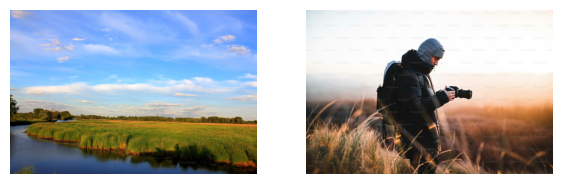

In [10]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# 두 개의 이미지 URL을 지정합니다.
url1 = wisconsin_url
url2 = 'https://plus.unsplash.com/premium_photo-1673448391005-d65e815bd026?q=80&w=2070&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D'

# 이미지를 불러오는 함수
def load_image(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url,headers=headers)
    img = Image.open(BytesIO(response.content))
    return img

# 이미지를 불러옵니다.
img1 = load_image(url1)
img2 = load_image(url2)

# 이미지를 출력합니다.
fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img1)
axes[0].axis('off')  # 축 제거
axes[1].imshow(img2)
axes[1].axis('off')  # 축 제거
plt.show()

In [11]:
# 다른 이미지 입력 질의
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role":"user",
            "content": [
                { "type":"text","text":"이 이미지들에 무엇이 있나요? 이들 사이에 차이가 있나요?" },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url1
                    },
                },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url2
                    },
                },
            ],
        }
    ],
    max_tokens=300,    
)

print(response.choices[0].message.content)

첫 번째 이미지는 평화로운 자연 풍경을 담고 있으며, 강과 초원이 넓게 펼쳐져 있는 모습입니다. 하늘은 맑고 구름이 떠 있습니다.

두 번째 이미지는 한 사람이 카메라를 들고 자연을 촬영하고 있는 장면입니다. 사람은 따뜻한 옷을 입고 있으며, 주변의 초원과 결합된 모습입니다.

두 이미지의 차이는 첫 번째 이미지는 풍경을 보여주는 반면, 두 번째 이미지는 활동하는 사람을 중심으로 한 구성입니다.


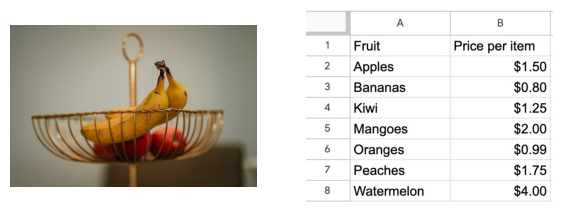

In [12]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# 두 개의 이미지 URL을 지정합니다.
url1 = 'https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/banana-apple.jpg'
url2 = 'https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/pricelist.jpg'

# 이미지를 불러오는 함수
def load_image(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    return img

# 이미지를 불러옵니다.
img1 = load_image(url1)
img2 = load_image(url2)

# 이미지를 출력합니다.
fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img1)
axes[0].axis('off')  # 축 제거
axes[1].imshow(img2)
axes[1].axis('off')  # 축 제거
plt.show()

In [13]:
# 두 개의 이미지 입력 질의
response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {
            "role":"user",
            "content": [
                { "type":"text","text":"이 이미지들에 무엇이 있는지 자세히 설명해주세요." },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url1
                    },
                },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url2
                    },
                },
            ],
        }
    ],
    max_tokens=300,    
)

print(response.choices[0].message.content)

첫 번째 이미지에는 금속 바구니 안에 과일들이 담겨 있습니다. 바나나와 빨간색 사과들이 보입니다.

두 번째 이미지는 가격표가 담긴 스프레드시트입니다. 이 목록은 과일 이름과 각 과일의 개당 가격을 나열합니다:

- Apples: $1.50
- Bananas: $0.80
- Kiwi: $1.25
- Mangoes: $2.00
- Oranges: $0.99
- Peaches: $1.75
- Watermelon: $4.00


In [14]:
# 두 개의 이미지로 정보 알아오기
response = client.chat.completions.create(
    # model="gpt-4o-mini",  # $4.60
    model="gpt-4o",         # $6.10
    messages=[
        {
            "role":"user",
            "content": [
                { "type":"text","text":"첫 번째 이미지의 과일들의 총 가격을 계산하세요.사과는 총 3개야" },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url1
                    },
                },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url2
                    },
                },
            ],
        }
    ],
    max_tokens=300,    
)

print(response.choices[0].message.content)

사과 3개와 바나나 2개의 총 가격을 계산해 보겠습니다.

- 사과: $1.50 × 3 = $4.50
- 바나나: $0.80 × 2 = $1.60

총 가격: $4.50 + $1.60 = $6.10

총 가격은 $6.10입니다.


In [15]:
# 두 개의 이미지로 정보 알아오기

prompt = """
이 단계들을 통해 질문에 답하세요:
1단계: 첫 번째 이미지에 어떤 종류의 과일들이 있는지 확인하세요. 
2단계: 각 과일의 수량을 세세요. 
3단계: 첫 번째 이미지에 있는 각 과일에 대해 가격표에서 가격을 확인하세요. 
4단계: 각 과일의 소계 가격을 계산하세요. 
5단계: 소계 가격들을 사용하여 과일들의 총 가격을 계산하세요.

각 단계에서 취한 조치를 설명하고 답변하세요.
"""

response = client.chat.completions.create(
    model="gpt-4o",        
    messages=[
        {
            "role":"user",
            "content": [
                { "type":"text","text":prompt },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url1
                    },
                },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url2
                    },
                },
            ],
        }
    ],
    max_tokens=300,    
)

print(response.choices[0].message.content)

1단계: 첫 번째 이미지에 어떤 종류의 과일들이 있는지 확인하세요.
- 바나나와 사과가 있습니다.

2단계: 각 과일의 수량을 세세요.
- 바나나: 2개
- 사과: 3개

3단계: 첫 번째 이미지에 있는 각 과일에 대해 가격표에서 가격을 확인하세요.
- 바나나: $0.80
- 사과: $1.50

4단계: 각 과일의 소계 가격을 계산하세요.
- 바나나 소계: 2개 × $0.80 = $1.60
- 사과 소계: 3개 × $1.50 = $4.50

5단계: 소계 가격들을 사용하여 과일들의 총 가격을 계산하세요.
- 총 가격: $1.60 (바나나) + $4.50 (사과) = $6.10

총 가격은 $6.10입니다.


### [4] 이미지와 인터페이스 이해하기

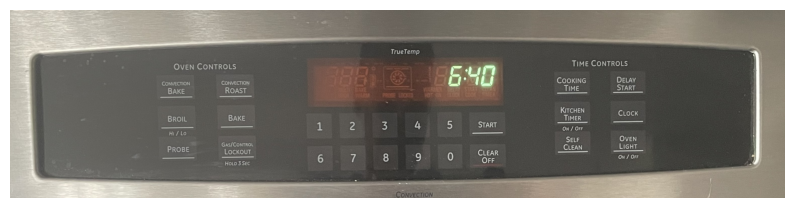

In [16]:
# 이미지 URL
url = "https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/stove.jpg"

# URL에서 이미지 가져오기
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# 이미지 출력
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  # 축 제거
plt.show()

In [17]:
prompt = """
이 기기의 시계를 어떻게 리셋할 수 있나요?
한국어로 먼저 설명서를 제공하고 뒤에 영어로 사용 설명서를 제공하세요.
사용 설명서에 버튼이 포함된 경우, 해당 버튼들이 물리적으로 어디에 위치해 있는지도 설명해 주세요.
"""

response = client.chat.completions.create(
    model="gpt-4o",        
    messages=[
        {
            "role":"user",
            "content": [
                { "type":"text","text":prompt },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url
                    },
                },
            ],
        }
    ],
    max_tokens=500,    
)

print(response.choices[0].message.content)

한국어 사용 설명서:

1. **시계 설정 준비**
   - 오른쪽 패널의 중앙에 있는 "Clock" 버튼을 찾아 누르세요.

2. **시간 설정**
   - 숫자 키패드를 사용하여 현재 시간을 입력하세요. 
   - 12시간 형식으로 시간을 입력하세요. (예: 오후 2시 30분은 "0230"으로 입력)

3. **설정 완료**
   - 시간 입력 후, "Start" 버튼, 오른쪽 패널 하단에 있는 버튼을 눌러 설정을 완료하세요.

**버튼 위치**
- "Clock" 버튼은 오른쪽 패널의 중앙 근처에 위치해 있습니다.
- 숫자 키패드는 디스플레이 아래 중앙에 있습니다.
- "Start" 버튼은 숫자 키패드의 우측에 있습니다.

---

English User Manual:

1. **Prepare to Set the Clock**
   - Find and press the "Clock" button located in the center of the right panel.

2. **Set the Time**
   - Use the numeric keypad to enter the current time.
   - Enter the time in a 12-hour format. (For example, 2:30 PM would be entered as "0230")

3. **Finalize the Setting**
   - After entering the time, press the "Start" button, which is on the lower right side of the numeric keypad, to complete the setting.

**Button Locations**
- The "Clock" button is located near the center of the right panel.
- The numeric keypad is located below the display in the center.
- The "Start" but

In [18]:
prompt = """
이 기기로 4인분 가족을 위한 빵을 굽는 방법을 한글로 설명해주세요.
"""

response = client.chat.completions.create(
    model="gpt-4o",        
    messages=[
        {
            "role":"user",
            "content": [
                { "type":"text","text":prompt },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url
                    },
                },
            ],
        }
    ],
    max_tokens=500,    
)

print(response.choices[0].message.content)

이 오븐으로 4인분의 빵을 굽는 방법은 다음과 같습니다.

1. **재료 준비**:
   - 밀가루, 물, 이스트, 소금, 설탕 등의 재료를 준비합니다.
   - 반죽을 만들고 발효시키세요.

2. **오븐 예열**:
   - 오븐의 "BAKE" 버튼을 눌러 예열을 시작합니다.
   - 온도를 180°C(356°F)로 설정합니다. 오븐이 도달할 때까지 기다리세요.

3. **반죽 준비**:
   - 발효가 완료된 반죽을 원하는 크기로 나누어 팬에 올립니다.

4. **오븐에 빵 넣기**:
   - 예열된 오븐에 팬을 넣고 굽습니다.

5. **시간 설정**:
   - "COOKING TIME" 버튼을 사용하여 굽는 시간을 25-30분으로 설정합니다.

6. **굽기 시작**:
   - "START" 버튼을 눌러 굽기를 시작하세요.

7. **완료 확인**:
   - 시간이 지나면 빵이 고르게 구워졌는지 확인하세요. 빵의 윗면이 노릇하게 변하면 완성입니다.

8. **식히기**:
   - 오븐에서 빵을 꺼내어 식힙니다.

이제 맛있는 빵을 가족들과 함께 즐기세요!


### [5] 입력 이미지의 유사점과 차이점 분석하기

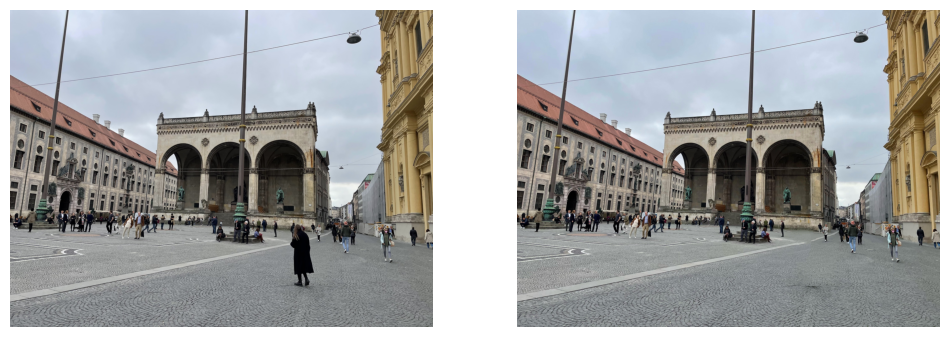

In [19]:
# 두 개의 이미지 URL을 지정합니다.
url1 = "https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/landmark1.jpg"
url2 = "https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/landmark2.jpg"

# 이미지를 불러오는 함수
def load_image(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    return img

# 이미지를 불러옵니다.
img1 = load_image(url1)
img2 = load_image(url2)

# 이미지를 출력합니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 12))
axes[0].imshow(img1)
axes[0].axis('off')  # 축 제거
axes[1].imshow(img2)
axes[1].axis('off')  # 축 제거
plt.show()

In [20]:
prompt = """
두 개의 이미지에 대하여 다음 내용을 답하세요:
1. 첫번째 이미지에는 무엇이 보이나요?
2. 두 이미지 사이에 어떤 유사점이 있나요?
3. 첫번째 이미지와 두번째 이미지의 내용 또는 사람의 수에서 어떤 차이가 있나요?
"""

response = client.chat.completions.create(
    # model="gpt-4o",        
    model="gpt-5",        
    messages=[
        {
            "role":"user",
            "content": [
                { "type":"text","text":prompt },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url1
                    },
                },
                {
                    "type":"image_url",
                    "image_url":{
                        "url": url2
                    },
                },
            ],
        }
    ],
    # max_tokens=300,    
)

print(response.choices[0].message.content)

1) 첫 번째 이미지: 넓은 광장과 자갈 포장길이 보이고, 중앙에는 세 개의 큰 아치가 있는 석조 로지아(안쪽과 앞에 청동상들)가 있습니다. 왼쪽엔 긴 회색 건물, 오른쪽엔 노란색의 웅장한 건물 외벽이 서 있고, 가로등과 공중 전선, 흐린 하늘 아래 많은 보행자와 관광객들이 걷거나 서 있습니다.

2) 유사점:
- 같은 장소를 거의 같은 각도에서 촬영
- 동일한 건물(아치형 구조물, 왼쪽 긴 건물, 오른쪽 노란 건물)과 거리 요소(전선, 가로등, 동상) 존재
- 날씨와 조도, 광장의 분위기와 사람들의 활동이 유사

3) 차이점(내용/사람 수):
- 두 사진은 사실상 동일해 보이며, 사람들의 위치와 수에서도 눈에 띄는 차이가 없습니다. 있다면 화면 가장자리의 아주 미세한 프레이밍 차이 정도만 보입니다.


## [6] Video 분석하기
: https://cookbook.openai.com/examples/gpt_with_vision_for_video_understanding

In [21]:
# ! pip install opencv-python

In [22]:
from IPython.display import display, Image, Audio
import cv2
import base64
import requests
import numpy as np
import time

# Step 1: Download the video file from the URL
video_url = "https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/photography.mp4"
response = requests.get(video_url, stream=True)

# Save the video locally
with open("downloaded_video.mp4", 'wb') as video_file:
    for chunk in response.iter_content(chunk_size=1024):
        if chunk:
            video_file.write(chunk)

# Step 2: Use OpenCV to process the downloaded video
video = cv2.VideoCapture("downloaded_video.mp4")

base64Frames = []
while video.isOpened():
    success, frame = video.read()
    if not success:
        break
    _, buffer = cv2.imencode(".jpg", frame)
    base64Frames.append(base64.b64encode(buffer).decode("utf-8"))

video.release()
print(len(base64Frames), "frames read.")  # 538 frames read.

538 frames read.


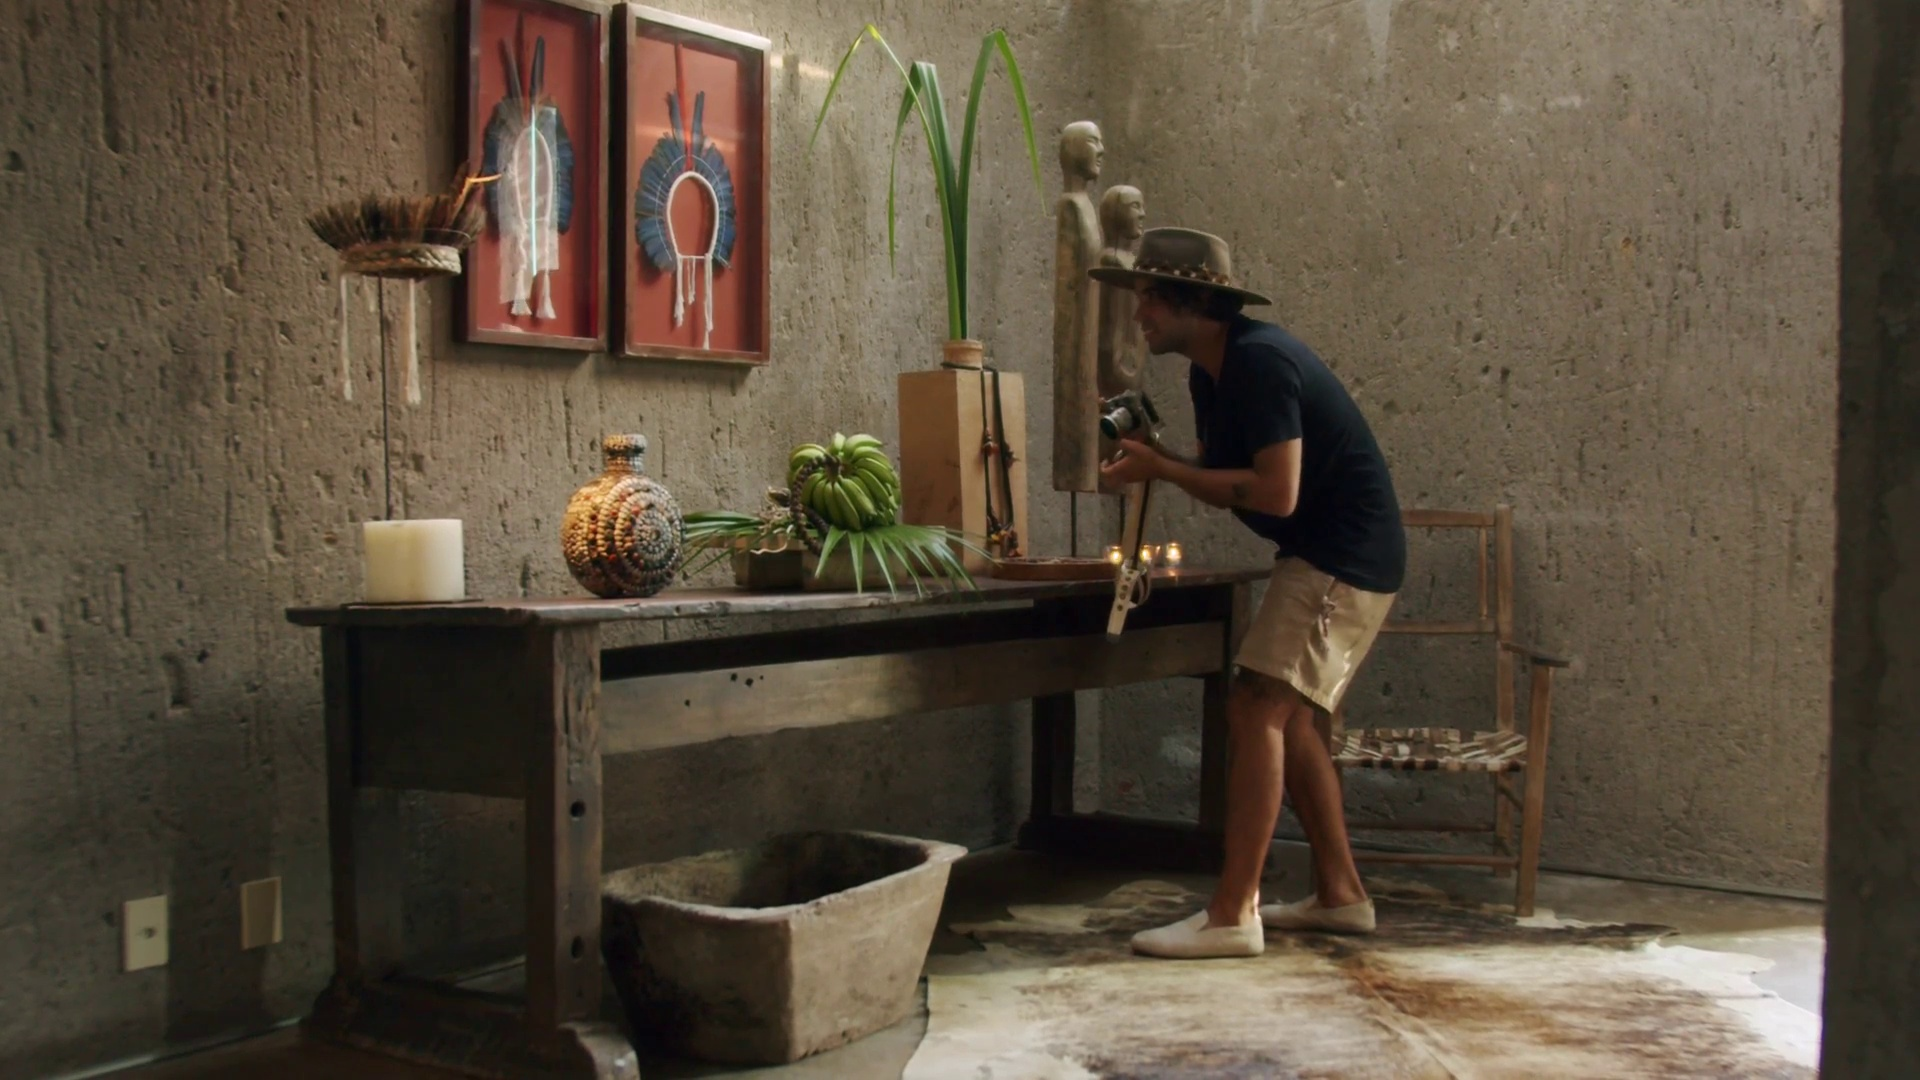

In [23]:
display_handle = display(None, display_id=True)
for img in base64Frames:
    display_handle.update(Image(data=base64.b64decode(img.encode("utf-8"))))
    time.sleep(0.025)

In [24]:
PROMPT_MESSAGES = [
    {
        "role": "user",
        "content": [
            "이것은 제가 업로드하고자 하는 영상의 프레임들입니다. 영상을 함께 업로드할 때 사용할 수 있는 설명을 작성해 주세요.",
            *map(lambda x: {"image": x, "resize": 768}, base64Frames[0::50]),  # 11장(538/50)
        ],
    },
]

params = {
    "model" : "gpt-4o",
    "messages" : PROMPT_MESSAGES,
    "max_tokens" : 500,
}

result = client.chat.completions.create(**params)
print(result.choices[0].message.content)

이 영상에서는 벽돌로 된 아늑한 공간에서 정통적인 장식들이 놓인 테이블 앞에서 사진을 찍는 장면을 담고 있습니다. 자연광이 부드럽게 비치는 이곳에서는 전통 예술 작품과 열대 식물들이 조화롭게 어우러져 있어 평화로운 분위기를 만끽할 수 있습니다. 사진 촬영을 통해 사람들은 예술과 자연이 만나는 이 특별한 순간을 기록하고 있습니다.


In [25]:
# def add(x):
#     return x + 10
    
# ret = map(add,[1,2,3,4,5,6,7,8,9,10])
# list(ret)

ret = map(lambda x: x + 10,[1,2,3,4,5,6,7,8,9,10])
list(ret)

[11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [26]:
def add(a,b):
    return a + b

d = {"a":10,"b":20}

print(add(10,20))
print(add(a=10,b=20))
print(add(**d))    # 키워드 인수, add(a=10,b=20)와 동일한 결과

30
30
30


## [7] Text-to-speech (TTS)
: https://openai.com/index/new-models-and-developer-products-announced-at-devday/

In [27]:
#  영문 스크립트 생성
PROMPT_MESSAGES = [
    {
        "role": "user",
        "content": [
            "These are frames of a video. Create a short voiceover script in the style of David Attenborough. Only include the narration.",
            *map(lambda x: {"image": x, "resize": 768}, base64Frames[0::50]),  # 11장(538/50)
        ],
    },
]

params = {
    "model" : "gpt-4o",
    "messages" : PROMPT_MESSAGES,
    "max_tokens" : 500,
}

result = client.chat.completions.create(**params)
print(result.choices[0].message.content)

In a serene corner of the world, we find a solitary explorer, quietly observing the artistry and remnants of cultures past. Surrounded by relics, each with its own tale, he captures the essence of a time gone by. The stillness is punctuated only by the faint click of the camera, preserving a dialogue between the present and antiquity. Here, in this sanctuary of human expression, history whispers its secrets to those who listen.


In [28]:
reponse = requests.post(
    "https://api.openai.com/v1/audio/speech",
    headers = {
        "Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}",
    },
    json={
        "model": "tts-1-hd",
        "input": result.choices[0].message.content,
        "voice": "alloy",
    },
)

audio = b""   
for chunk in reponse.iter_content(chunk_size=1024*1024):
    audio += chunk

Audio(audio)    

In [29]:
#  한글 스크립트 생성
PROMPT_MESSAGES = [
    {
        "role": "user",
        "content": [
            "이것들은 영상의 프레임입니다. 짧은 내레이션 대본을 한국어로 작성해주세요. 내레이션만 포함하세요.",
            *map(lambda x: {"image": x, "resize": 768}, base64Frames[0::50]),  # 11장(538/50)
        ],
    },
]

params = {
    "model" : "gpt-4o",
    "messages" : PROMPT_MESSAGES,
    "max_tokens" : 500,
}

result = client.chat.completions.create(**params)
print(result.choices[0].message.content)

이곳은 시간이 멈춘 듯한 공간, 세월의 흔적이 깃든 벽과 자연의 요소들이 어우러져 신비로움을 더합니다.

찰칵, 사진 속에 담기는 순간은 이 모든 것을 영원히 간직합니다.

카메라 렌즈 너머로 보이는 세상은 무한한 이야기를 담고 있습니다.

이 조용한 공간에서, 우리는 과거와 현재를 연결하는 예술의 힘을 느낄 수 있습니다.


In [30]:
reponse = requests.post(
    "https://api.openai.com/v1/audio/speech",
    headers = {
        "Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}",
    },
    json={
        "model": "tts-1-hd",
        "input": result.choices[0].message.content,
        "voice": "onyx",
    },
)

audio = b""   
for chunk in reponse.iter_content(chunk_size=1024*1024):
    audio += chunk

Audio(audio)    

## [8] GPT Image 모델 : 이미지 생성

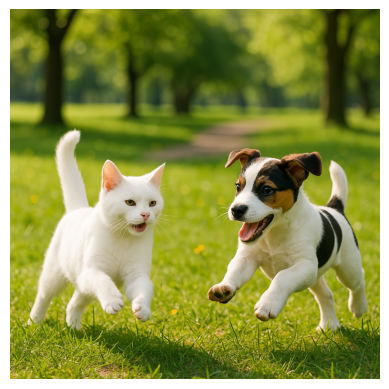

In [31]:
from openai import OpenAI
import base64
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

client = OpenAI()

response = client.images.generate(
    model="gpt-image-1",
    prompt="하얀 고양이와 바둑이 강아지가 공원에서 함께 뛰어노는 모습",
    size="1024x1024"
)

# Base64 → 이미지
image_base64 = response.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

img = Image.open(BytesIO(image_bytes))

plt.imshow(img)
plt.axis("off")
plt.show()

In [32]:
# !pip install "numpy<2"

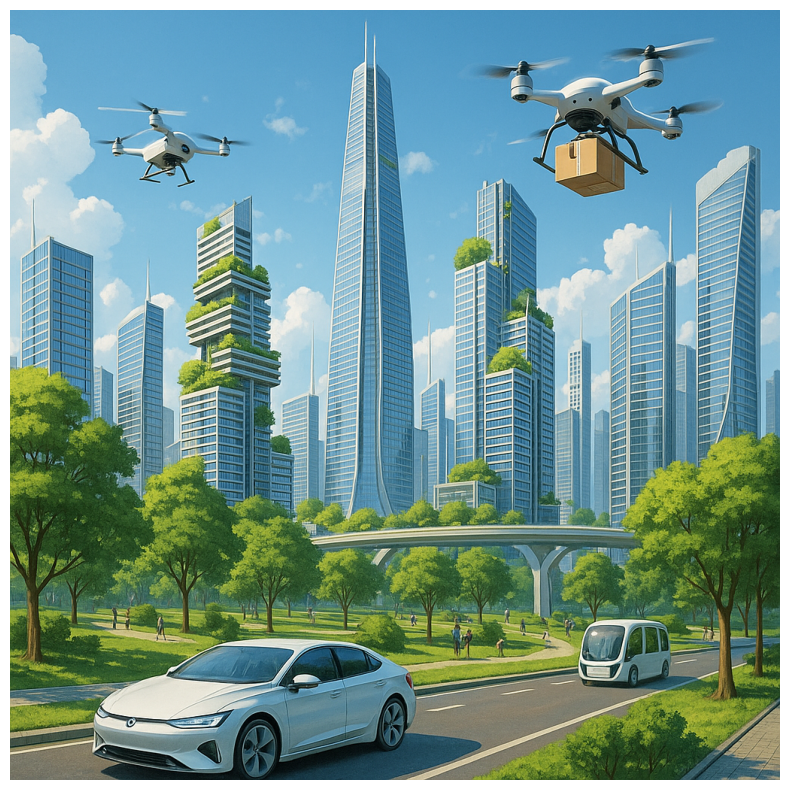

In [33]:
from openai import OpenAI
import base64
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

client = OpenAI()

response = client.images.generate(
    model="gpt-image-1",
    prompt="미래의 서울 도시 모습, 자율주행 자동차와 드론이 다니고 초고층 빌딩 사이에 나무와 공원이 조성된 친환경 스마트시티",
    size="1024x1024"
)

# Base64 데이터 추출
image_base64 = response.data[0].b64_json

# Base64 → 이미지
image_bytes = base64.b64decode(image_base64)
img = Image.open(BytesIO(image_bytes))

# 이미지 출력
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()